In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

# model = Sequential()
# model.add(Dense(units=10,
#                activation='relu'))

model = Sequential([
    Dense(units=10, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

plot_model(model, to_file='./model.png', show_shapes=True)

ValueError: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.

In [16]:
# mnist 구현(DNN형태 구현)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.utils import plot_model # 그림으로 우리 모델을 보여는 코드

In [17]:
# row data loading
df = pd.read_csv('./data/mnist/train.csv')
display(df.head())

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# 결측치, 이상치, 데이터 불균형 없어요
# 종속변수, 독립변수 분리

x_data = df.drop('label', axis=1, inplace=False).values
t_data = df['label'].values.reshape(-1,1)

In [19]:
# train 과 test 분리
x_data_train, x_data_test, t_data_train, t_data_test =\
train_test_split(x_data,
                t_data,
                test_size=0.2,
                stratify=t_data,
                random_state=42)

In [20]:
# 정규화
scaler = MinMaxScaler()
scaler.fit(x_data_train)
x_data_train_norm = scaler.transform(x_data_train)
x_data_test_norm = scaler.transform(x_data_test)

In [21]:
# model
# Functional API를 이용하기 위해서는 먼저
# Input layer부터 정의해야 해요!

input_layer = Input(shape=(784,),
                   name='InputLayer')

# 함수호출하는 것처럼 레이어를 연결해요
# x1 = Flatten(name='FlattenLayer')(input_layer) 
# x2 = Dense(units=256,
#           activation='relu',
#           name='Hidden_1')(x1)
# x3 = Dense(units=64,
#           activation='relu',
#           name='Hidden_2')(x2)
# x4 = Dense(units=10,
#           activation='softmax',
#           name='Hidden_3')(x3)

x = Flatten(name='FlattenLayer')(input_layer) 
x = Dense(units=256,
          activation='relu',
          name='Hidden_1')(x)
x = Dense(units=64,
          activation='relu',
          name='Hidden_2')(x)
x = Dense(units=10,
          activation='softmax',
          name='Hidden_3')(x)

In [22]:
# model 생성
model = Model(inputs=input_layer,
             outputs=x)  #[]로 여러개를 사용할 수 있다!
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 InputLayer (InputLayer)     [(None, 784)]             0         
                                                                 
 FlattenLayer (Flatten)      (None, 784)               0         
                                                                 
 Hidden_1 (Dense)            (None, 256)               200960    
                                                                 
 Hidden_2 (Dense)            (None, 64)                16448     
                                                                 
 Hidden_3 (Dense)            (None, 10)                650       
                                                                 
Total params: 218058 (851.79 KB)
Trainable params: 218058 (851.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


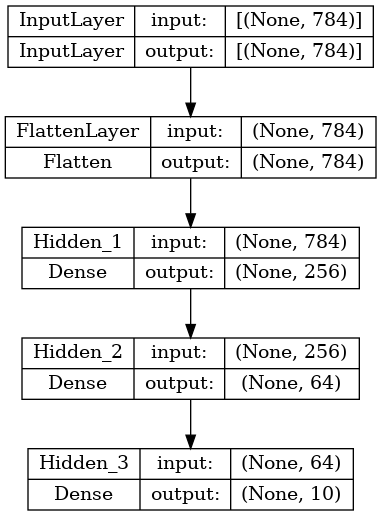

In [23]:
plot_model(model,
          show_shapes=True,
          show_layer_names=True)

In [24]:
# 다중입력은 아니고 입력된 데이터가 여러 레이어로 들어가서
# 다르게 처리되는 예를 하나 보아요!

# Mnist를 구현하는데 DNN구현방식, CNN구현방식이 있는데
# 이 두가지를 다 구현해서 그 결과를 합쳐서 학습을 진행
# (모델 두개를 이용해서 새로운 학습으로 모델을 완성해보겠어요!)

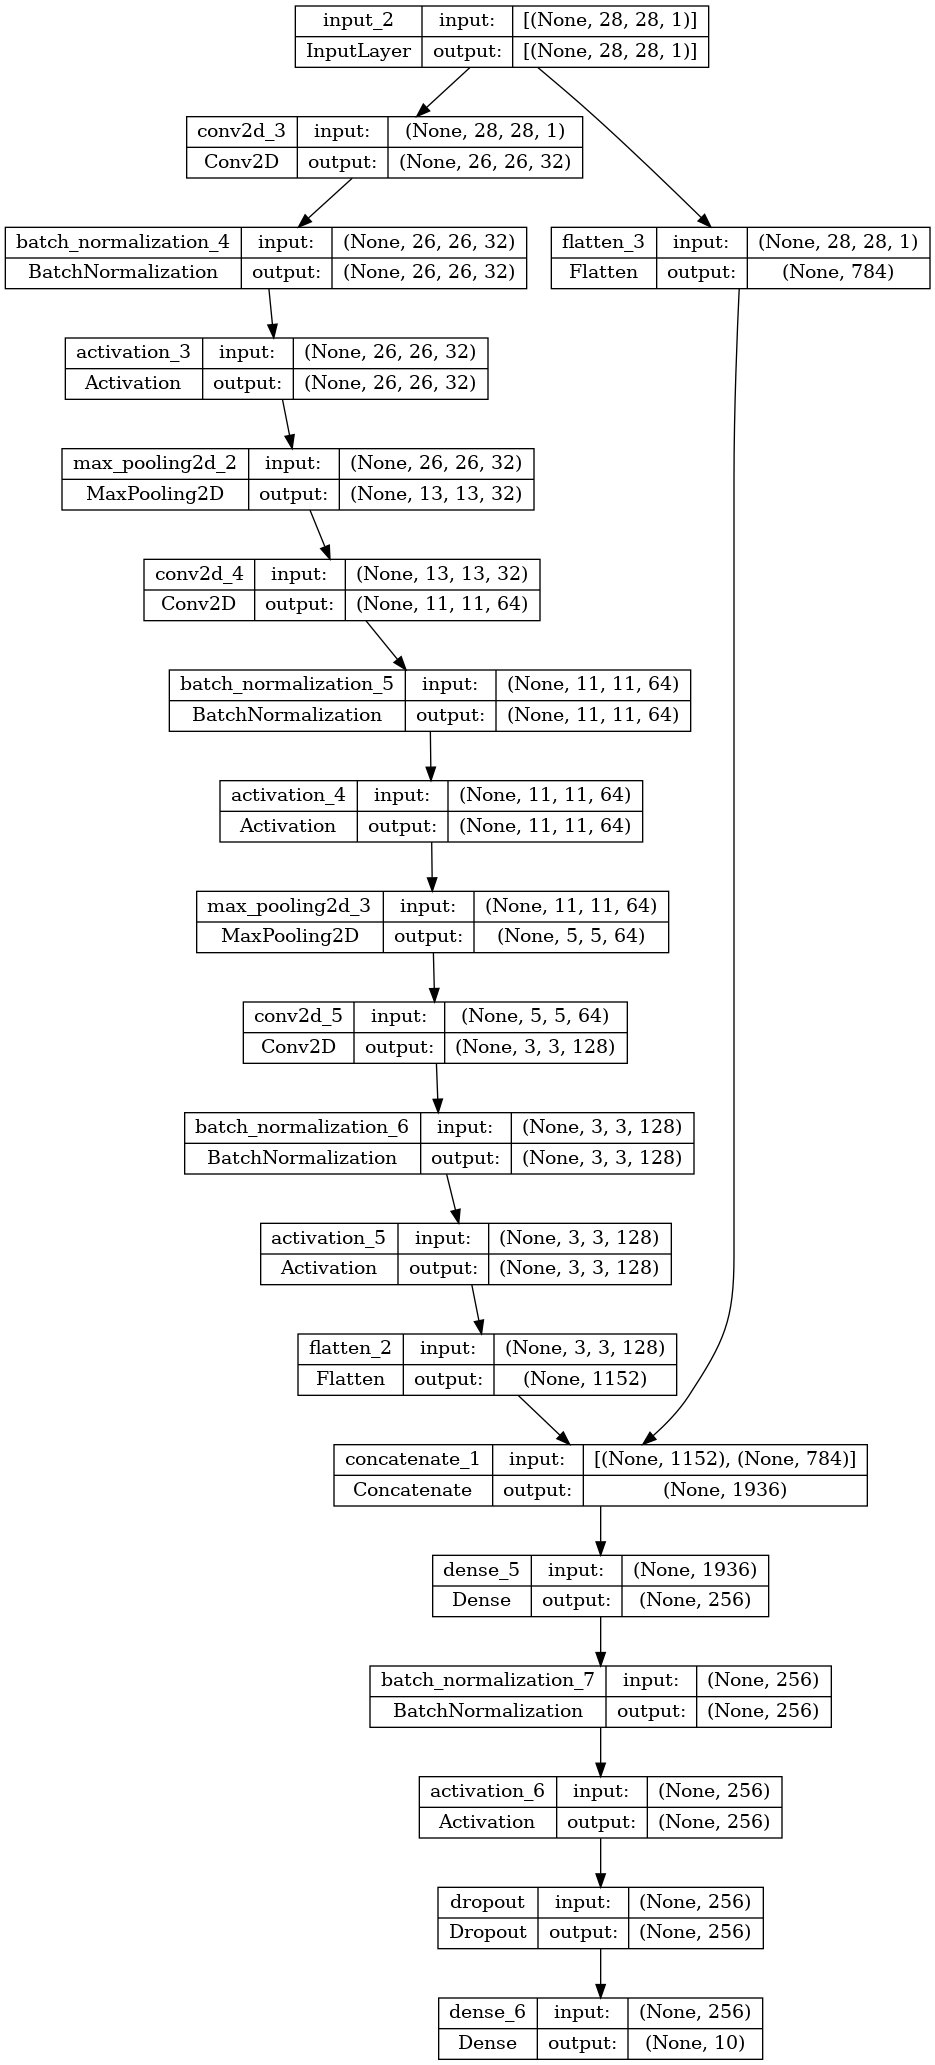

In [26]:
# model 구현
inputs = Input(shape=(28,28,1))  #CNN은 3차원으로 입력을 받음

from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import Concatenate, Dropout
#CNN
conv_1 = Conv2D(filters=32,
               kernel_size=(3,3),
               strides=(1,1))(inputs)
batch_1 = BatchNormalization()(conv_1)
activation_1 = Activation('relu')(batch_1)
pool_1 = MaxPooling2D(pool_size=(2,2))(activation_1)

conv_2 = Conv2D(filters=64,
               kernel_size=(3,3),
               strides=(1,1))(pool_1)
batch_2 = BatchNormalization()(conv_2)
activation_2 = Activation('relu')(batch_2)
pool_2 = MaxPooling2D(pool_size=(2,2))(activation_2)

conv_3 = Conv2D(filters=128,
               kernel_size=(3,3),
               strides=(1,1))(pool_2)
batch_3 = BatchNormalization()(conv_3)
activation_3 = Activation('relu')(batch_3)

flatten_conv = Flatten()(activation_3)

#DNN
flatten = Flatten()(inputs)

# 결과를 합쳐요!
concat = Concatenate()([flatten_conv, flatten])

# 히든 레이어
dense_1 = Dense(units=256)(concat)
batch_1 = BatchNormalization()(dense_1)
activation_1 = Activation('relu')(batch_1)

# Dropout
dropout = Dropout(rate=0.4)(activation_1)

# output layer
output = Dense(units=10,
              activation='softmax')(dropout)

model = Model(inputs=inputs,
             outputs=output)
plot_model(model,
          show_shapes=True)

In [29]:
# 모델의 다중출력을 구현해 보아요!
# Sequential model로는 할 수 없어요 무조건 1개만 나오니까
# Functional API로는 할 수 있어요
# 다중분류를 위한 데이터는 준비되어 있어요 (x_data, t_data)
# 홀짝을 구분하기 위한 이진분류의 데이터는 준비되어 있지 않아요
# (x_data는 있는데 t_data가 없어요 그래서 t_data부터 만들어야 해요)
# 위에서 만들어 놓은 t_data가 있어요(0~9까지 숫자가 들어가 있어요)

t_data_odd_train = []  # 짝수는 0, 홀수는 1
for t in t_data_train:
    if t % 2 == 0:
        t_data_odd_train.append(0)
    else:
        t_data_odd_train.append(1)

print(t_data_train[:5])
print(t_data_odd_train[:5])        
t_data_odd_train = np.array(t_data_odd_train).reshape(-1,1)

t_data_odd_test = []  # 짝수는 0, 홀수는 1
for t in t_data_test:
    if t % 2 == 0:
        t_data_odd_test.append(0)
    else:
        t_data_odd_test.append(1)
t_data_odd_test = np.array(t_data_odd_test).reshape(-1,1)

[[2]
 [3]
 [6]
 [4]
 [0]]
[0, 1, 0, 0, 0]


In [30]:
# 다중 출력을 구현하려고 해요
# 입력은 1개의 입력을 받을거에요
# 출력이 여러개로 나와야 하니까 label을 추가적으로 생성
# 다중분류(숫자맞추기)+이진분류(홀짝맞추기)
# 출력만 두개로 나오면 되는거니까
# 입력(픽셀정보) -> CNN통과 -> 다중분류 출력
# 입력(픽셀정보) -> 일반 Dense통과 -> 이진분류 출력

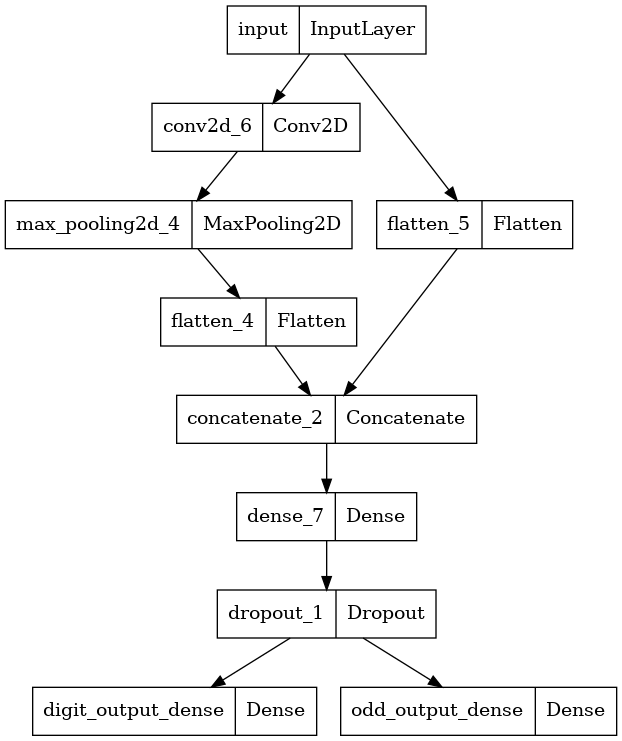

In [32]:
# 모델 구현
inputs = Input(shape=(28,28,1),
              name='input')
conv = Conv2D(filters=32,
             kernel_size=(3,3),
             strides=(1,1),
             activation='relu')(inputs)
pool = MaxPooling2D(pool_size=(2,2))(conv)

flatten_conv = Flatten()(pool)
flatten_input = Flatten()(inputs)

concat = Concatenate()([flatten_conv, flatten_input])

dense_1 = Dense(units=256,
               activation='relu')(concat)

dropout = Dropout(rate=0.4)(dense_1)

digit_output = Dense(units=10,
                    activation='softmax',
                    name='digit_output_dense')(dropout)
odd_output = Dense(units=1,
                  activation='sigmoid',
                  name='odd_output_dense')(dropout)
model = Model(inputs=inputs,
             outputs=[digit_output,odd_output])

plot_model(model)


In [33]:
# model 설정
model.compile(optimizer=Adam(learning_rate=1e-3),
             loss={
                 'digit_output':'sparse_categorical_crossentropy',
                 'odd_output':'binary_crossentropy'
             },
             metrics=['accuracy'])

In [37]:
# model 학습
model.fit(x_data_train_norm.reshape(-1,28,28,1),
         {
          'digit_output':t_data_train,
          'odd_output':t_data_odd_train
         },
         epochs=10,
         batch_size=100,
         verbose=1)

Epoch 1/10


ValueError: in user code:

    File "/home/govlept1004/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "/home/govlept1004/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1322, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/govlept1004/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1303, in run_step  **
        outputs = model.train_step(data)
    File "/home/govlept1004/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1081, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "/home/govlept1004/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1139, in compute_loss
        return self.compiled_loss(
    File "/home/govlept10